# Assignment: Data Wrangling

### Reading material: `tidy_data.pdf`

**Q1.** This question provides some practice cleaning variables which have common problems.
1. For `./data/airbnb_hw.csv`, clean the `Price` variable as well as you can, and explain the choices you make. How many missing values do you end up with? (Hint: What happens to the formatting when a price goes over 999 dollars, say from 675 to 1,112?)
2. For the Minnesota police use of for data, `./data/mn_police_use_of_force.csv`, clean the `subject_injury` variable, handling the NA's; this gives a value `Yes` when a person was injured by police, and `No` when no injury occurred. What proportion of the values are missing? Is this a concern? Cross-tabulate your cleaned `subject_injury` variable with the `force_type` variable. Are there any patterns regarding when the data are missing? 

**Q2.** Go to https://sharkattackfile.net/ and download their dataset on shark attacks (Hint: `GSAF5.xls`).

1. Open the shark attack file using Pandas. It is probably not a csv file, so `read_csv` won't work.
2. Drop any columns that do not contain data.
3. Clean the year variable. Describe the range of values you see. Filter the rows to focus on attacks since 1940. Are attacks increasing, decreasing, or remaining constant over time?
4. Clean the Age variable and make a histogram of the ages of the victims.
5. What proportion of victims are male?
6. Clean the `Type` variable so it only takes three values: Provoked and Unprovoked and Unknown. What proportion of attacks are unprovoked?

---

## *Phase 1: Solution without AI

Complete all questions in the following cells without generative AI. Then commit and push the
notebook before beginning Phase 2.

**Declaration:** I completed this version without generative AI.

**Student(s):** Andrew Kim

**Date:** 9/2/2026

In [213]:
# Your Phase 1 solution to the problem goes here.
import numpy as np
import matplotlib as plt
import pandas as pd


In [214]:
# Q1) 1 
df1 = pd.read_csv("data/airbnb_hw.csv", thousands=',')
print('max price:', df1.Price.max(),'\n')
print("airbnb price missing values:", df1.Price.isna().sum())

# read csv with thousands argument to denote comma as thousands separator
# no missing values, column looks clean

max price: 10000 

airbnb price missing values: 0


In [215]:
# Q1) 2
df2 = pd.read_csv('data/mn_police_use_of_force.csv')
print("missing values:", df2.subject_injury.isna().sum())
print('\n', df2.subject_injury.unique(),'\n')
print('percent of missing values:', df2.subject_injury.isna().sum()/(df2.subject_injury.count() + df2.subject_injury.isna().sum()))
print('\n', pd.crosstab(df2.subject_injury, df2.force_type, dropna=False))

# read csv and check for missing values
# print unique values for injury
# calculate percent of missing values
# create cross tab of injury and force type without dropping na values
# a majority of nan values come from bodily force which can be worrisome as bodily force has the potential to cause bodily harm, meaning a large amount of bodily harm could be going undocumented

missing values: 9848

 <StringArray>
[nan, 'No', 'Yes']
Length: 3, dtype: str 

percent of missing values: 0.7619342359767892

 force_type      Baton  Bodily Force  Chemical Irritant  Firearm  \
subject_injury                                                    
No                  0          1093                131        2   
Yes                 2          1286                 41        0   
NaN                 2          7051               1421        0   

force_type      Gun Point Display  Improvised Weapon  Less Lethal  \
subject_injury                                                      
No                             33                 34            0   
Yes                            44                 40            0   
NaN                            27                 74           87   

force_type      Less Lethal Projectile  Maximal Restraint Technique  \
subject_injury                                                        
No                                   1          

In [216]:
# Q2) 1
df3 = pd.read_excel('data/GSAF5.xls')
df3.head()
# read excel

,Date,Year,Type,Country,State,Location,Activity,Name,Sex,Age,...,Species,Source,pdf,href formula,href,Case Number,Case Number.1,original order,Unnamed: 21,Unnamed: 22
0,26th August,2026.0,Unprovoked,USA,Hawaii,"Ala Moana Beach Park, Oah'u",Surfing,Unknown Female,F,?,...,Tiger Shark,Keith Cowley: KHON: KITV:,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,23rd August,2026.0,Unprovoked,USA,Florida,Boca Grande (island in the keys),Wading on a sandbar,David Daniel,M,43,...,Large shark,Keith Cowley: Todd Smith: NBC 6: ABC News:,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,19th August,2026.0,Provoked,Reunion Island,Saint-Gilles-les-Baines,Outer Reef Roches Noires,Spearfishiong,Male,M,?,...,Bull shark 2.5m (8.2 ft),Todd Smith: Local Report Zinfos 874:,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,11th August,2026.0,Provoked,Ireland,Waterford,Ardemore County,Fishing,Sebastian Achim,M,27,...,1.5m (5ft) Blue shark,Keith Cowley: David Bargh: Irish Times BBC Met...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,8th August,2026.0,Unprovoked,USA,Maine,Scarborough Beach Park,Operation of Rescue Torpedo,Greg Wilfert,M,71,...,Great White Shark,WGME: CBS News: Keith Cowley,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [217]:
# Q2) 2
print(df3.isna().mean(),'\n')
print(df3['Unnamed: 21'].unique())
print(df3['Unnamed: 22'].unique())

df3.dropna(axis=1, how='all', inplace=True)
df3.drop(columns=['Unnamed: 21','Unnamed: 22'], inplace=True)

df3.columns
# check columns for proportion of missing data
# drop missing data and unnamed columns

Date              0.000000
Year              0.000281
Type              0.002529
Country           0.007025
State             0.068428
Location          0.079668
Activity          0.081917
Name              0.030631
Sex               0.081214
Age               0.420683
Injury            0.005058
Fatal Y/N         0.078825
Time              0.495574
Species           0.439933
Source            0.002810
pdf               0.044682
href formula      0.045384
href              0.045103
Case Number       0.044822
Case Number.1     0.044963
original order    0.044682
Unnamed: 21       0.999859
Unnamed: 22       0.999719
dtype: float64 

<StringArray>
[nan, 'stopped here']
Length: 2, dtype: str
<StringArray>
[nan, 'Teramo', 'change filename']
Length: 3, dtype: str


Index(['Date', 'Year', 'Type', 'Country', 'State', 'Location', 'Activity',
       'Name', 'Sex', 'Age', 'Injury', 'Fatal Y/N', 'Time', 'Species ',
       'Source', 'pdf', 'href formula', 'href', 'Case Number', 'Case Number.1',
       'original order'],
      dtype='str')

Year
0.0       129
5.0         1
77.0        1
1000.0      1
1500.0      1
Name: count, dtype: int64
Year
5.0       1
77.0      1
1000.0    1
1500.0    1
1518.0    1
Name: count, dtype: int64
<bound method Series.sort_values of 0       2026.0
1       2026.0
2       2026.0
3       2026.0
4       2026.0
         ...  
5578    1940.0
5579    1940.0
5580    1940.0
5581    1940.0
5582    1940.0
Name: Year, Length: 5581, dtype: float64>


<Axes: xlabel='Year'>

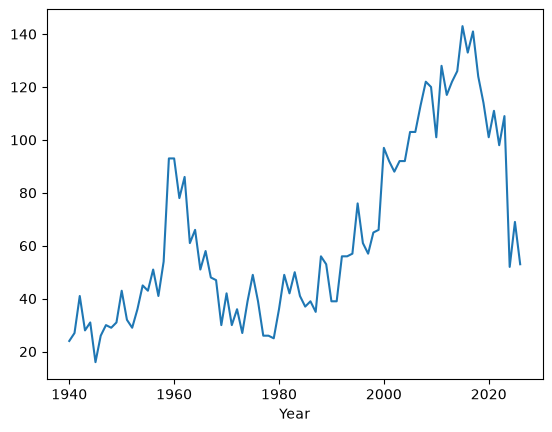

In [218]:
# Q2) 3
print(df3['Year'].value_counts().sort_index(ascending=True).head(5))
df3['Year'] = df3['Year'].replace(0, np.nan)
print(df3['Year'].value_counts().sort_index(ascending=True).head(5))

df3_1940 = df3[df3['Year'] >= 1940]
print(df3_1940.Year.sort_values)

df3_1940['Year'].value_counts().sort_index().plot()

#check the year column and replace 0 with na's
#filter attacks past 1940
#plot attacks and see that attacks generally have increased over time

['?' '43' '27' '71' '21' '69' '31' '13' '12' '17' '35' "20's" '19' '11'
 '20' '38' '39' '16' '22' '30+' "50's" '55' '26' '56' '24' '25' '61' '40'
 '14' '50+' '54' '48' '57' '8' '63' '9' '7' '85' '18' '66' '37' '42' '45'
 '30' '60' '40+' '29' 35 58 29 24 20 55 17 12 37 36 23 40 28 69 48 '60+'
 57 45 61 27 38 16 68 33 30 15 41 14 43 26 'Middle age' 18 21 49 25 46 19
 65 64 nan '46' '32' '10' '64' '62' '15' '52' '44' '47' '59' '50' '34'
 '30s' '20/30' '65' '20s' '77' '49' '!2' '73' '50s' '58' '67' '6' '41'
 '53' '68' '51' 39 51 10 13 60 '40s' 62 'teen' 8 22 32 56 'Teen' 42 50 'M'
 9 31 11 34 '!6' '!!' 47 7 71 59 53 54 75 '45 and 15' 73 52 70 4 63 44
 '28 & 22' '22, 57, 31' '60s' 67 74 '9 & 60' 'a minor' 6 3 82 '40?' 66 72
 '23' '36' '70' '18 months' '28' '33' '74' '3' '28 & 26' '5' '86'
 '18 or 20' '12 or 13' '46 & 34' '28, 23 & 30' 'Teens' 77 '36 & 26'
 '8 or 10' 84 '\xa0 ' ' ' '30 or 36' '6½' '21 & ?' '33 or 37' 'mid-30s'
 '23 & 20' 5 ' 30' '7      &    31' ' 28' '20?' "60's" '32 & 30'


<Axes: >

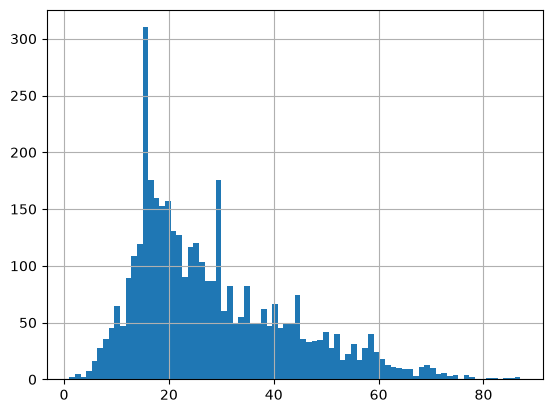

In [219]:
#Q2) 4
print(df3['Age'].unique())
print(df3['Age'].value_counts())

df3['Age'] = pd.to_numeric(df3['Age'], errors='coerce')
print(df3['Age'].describe())

df3['Age'].hist(bins=80)

#check age for non numeric values
#convert all values to numeric
#create histogram

In [ ]:
#Q2) 5
print(df3['Sex'].unique())
print(df3['Sex'].value_counts(dropna=False))

df3['Sex'] = df3['Sex'].astype('string').str.strip().str.upper()
df3['Sex'] = df3['Sex'].where(df3['Sex'].isin(['M', 'F']), other=np.nan)
print(df3['Sex'].value_counts())

print(f'percent of male attacks:', (df3['Sex'] == 'M').mean())

#inspect sex values
#normalize sex values and replace non normal ones with na
#calculate proportion of male attacks

<StringArray>
['F', 'M', <NA>]
Length: 3, dtype: string
Sex
M       5713
F        818
<NA>     586
Name: count, dtype: Int64
Sex
M    5713
F     818
Name: count, dtype: Int64
percent of male attacks: 0.8747511866482928


In [234]:
#Q2) 6
print(df3['Type'].unique())
print(df3["Type"].value_counts())

df3['Type'] = df3['Type'].astype('string').str.strip().str.lower()
df3['Type'] = df3['Type'].where(df3['Type'].isin(['unprovoked', 'provoked']), other=np.nan)

print(f'percent of unprovoked attacks', (df3['Type'] == 'unprovoked').mean())

<StringArray>
['unprovoked', 'provoked', <NA>]
Length: 3, dtype: string
Type
unprovoked    5263
provoked       649
Name: count, dtype: Int64
percent of unprovoked attacks 0.8902232746955345


## *Phase 2: AI-assisted Revision
Keep Phase 1 frozen.

- **Phase 1 commit SHA ID:** [To be provided]
- **AI tool and model used:** [To be provided]

### *Prompts used

1. [Paste prompt]
2. [Paste follow-up prompt]

### *AI-proposed changes


[Paste the AI's concise numbered list verbatim.]

1. ...
2. ...

### *Evaluation of AI suggestions


| Change | Decision | Reason and verification |
|---|---|---|
| 1 | Accept / modify / reject | ... |
| 2 | Accept / modify / reject | ... |

### *AI-assisted solution in full
After the evaluation of AI suggestions, incorporate the accepted revisions into your Phase 1 solution and provide the final Phase 2 solution in full in the following cells.

In [221]:
# Your Phase 2 solution to the problem goes here.


### *Reflection on AI assistance
In your own words without generative AI.

[In 150–300 words, describe the main improvements, AI mistakes or limitations, how the final solution was verified, and any remaining concerns.]